# Build matrix of interactions

In [ ]:
import os
import pandas as pd
from plip.structure.preparation import PDBComplex

# Protein names (longest first to avoid partial matches)
proteins = [
    "PDE4B_monomer_md",
    "PDE4B_dimer",
    "PDE4D_catalytic",
]

interaction_types = [
    "hydrophobic_contacts",
    "hbonds_ldon",
    "hbonds_pdon",
    "water_bridges",
    "saltbridge_lneg",
    "saltbridge_pneg",
    "pistacking",
    "pication_laro",
    "pication_paro",
    "halogen_bonds",
    "metal_complexes",
]

rows = []

pdb_folder = "../pdbs"

for pdb_file in sorted(os.listdir(pdb_folder)):
    print(pdb_file)
    if not pdb_file.endswith(".pdb"):
        continue

    basename = os.path.splitext(pdb_file)[0]

    # Identify protein and ligand from filename
    protein = None
    ligand = None
    for p in proteins:
        if basename.startswith(p + "_"):
            protein = p
            ligand = basename[len(p) + 1:]
            break

    if protein is None:
        print(f"Skipping {pdb_file}: protein not recognized.")
        continue

    pdb_path = os.path.join(pdb_folder, pdb_file)

    mol = PDBComplex()
    mol.load_pdb(pdb_path)
    mol.analyze()

    for bsid, inter in mol.interaction_sets.items():

        # # Ignore cofactors/ions (keep only the docked ligand)
        # if inter.ligand.hetid != "UNL":
        #     continue

        for interaction_type in interaction_types:

            if not hasattr(inter, interaction_type):
                continue

            interactions = getattr(inter, interaction_type)

            for i in interactions:

                rows.append({
                    "protein": protein,
                    "ligand": ligand,
                    "binding_site": bsid,
                    "interaction_type": interaction_type,
                    "residue_number": getattr(i, "resnr", None),
                    "residue_name": getattr(i, "restype", None),
                    "residue_chain": getattr(i, "reschain", None),
                })


PDE4B_catalytic_104775.pdb
PDE4B_catalytic_10559720.pdb
PDE4B_catalytic_107.pdb
PDE4B_catalytic_348154.pdb
PDE4B_catalytic_49831816.pdb
PDE4B_catalytic_6047.pdb
PDE4B_catalytic_Rrolipram_ph.pdb
PDE4B_catalytic_Srolipram_ph.pdb
PDE4B_catalytic_no12.pdb
PDE4B_catalytic_no13.pdb
PDE4B_catalytic_no17.pdb
PDE4B_catalytic_no7.pdb
PDE4B_catalytic_roflumilast.pdb
PDE4B_dimer_104775.pdb
PDE4B_dimer_10559720.pdb
PDE4B_dimer_107.pdb
PDE4B_dimer_348154.pdb
PDE4B_dimer_49831816.pdb
PDE4B_dimer_6047.pdb
PDE4B_dimer_Rrolipram_ph.pdb
PDE4B_dimer_Srolipram_ph.pdb
PDE4B_dimer_no12.pdb
PDE4B_dimer_no13.pdb
PDE4B_dimer_no17.pdb
PDE4B_dimer_no7.pdb
PDE4B_dimer_roflumilast.pdb
PDE4B_monomer_104775.pdb
PDE4B_monomer_10559720.pdb
PDE4B_monomer_107.pdb
PDE4B_monomer_348154.pdb
PDE4B_monomer_49831816.pdb
PDE4B_monomer_6047.pdb
PDE4B_monomer_Rrolipram_ph.pdb
PDE4B_monomer_Srolipram_ph.pdb
PDE4B_monomer_md_104775.pdb
PDE4B_monomer_md_10559720.pdb
PDE4B_monomer_md_107.pdb
PDE4B_monomer_md_348154.pdb
PDE4B_monomer_

In [ ]:
# convert the list of dict to df 
df = pd.DataFrame(rows)

# create res id column with name, position and chain
df["residue_id"] = (
    df["residue_name"].astype(str) +
    df["residue_number"].astype("Int64").astype(str) +
    ":" +
    df["residue_chain"].astype(str)
)

df.to_csv("protein_interactions.csv", index=False)


In [3]:
import pandas as pd

df = pd.read_csv('protein_interactions.csv')
#df = pd.read_csv('/home/gbiuser/Documents/vitoria/usp-masters/8-docking/interactions/protein_interactions.csv')    
print(df.shape)
print(df.columns)

(4693, 8)
Index(['protein', 'ligand', 'binding_site', 'interaction_type',
       'residue_number', 'residue_name', 'residue_chain', 'residue_id'],
      dtype='object')


In [4]:
df["protein"].value_counts()

protein
PDE4B_dimer        988
PDE4D_dimer        860
PDE4D_catalytic    851
PDE4B_monomer      717
PDE4B_catalytic    692
PDE4D_monomer      585
Name: count, dtype: int64

## Conserved residues across all complexes

In [5]:
# create df disconsindering ions
df_lig = df[df["binding_site"].str.startswith("UNL:")].copy()
# to_remove = ["PDE4B_catalytic"]
# df_lig = df_lig[~df_lig["protein"].isin(to_remove)]


In [6]:
# aggregate number of interactions based on number of proteins and ligands 
conserved = (
    df_lig.groupby("residue_id")
            .agg(
                n_proteins=("protein", "nunique"),
                n_ligands=("ligand", "nunique"),
                n_complexes=("protein", lambda x: len(set(zip(x, df.loc[x.index, "ligand"])))),
            )         
            .reset_index()
)

In [7]:
conserved.sort_values("n_complexes", ascending=False).head(20)

,residue_id,n_proteins,n_ligands,n_complexes
76,PHE618:A,2,20,39
72,PHE453:A,2,20,39
71,PHE452:A,2,18,32
104,TYR405:A,2,19,30
50,ILE582:A,3,20,30
23,GLN615:A,3,17,29
5,ASN401:A,2,17,29
47,ILE417:A,3,20,29
46,ILE416:A,2,18,29
19,GLN449:A,2,16,26


In [8]:
conserved.sort_values("n_proteins", ascending=False).head(20)

,residue_id,n_proteins,n_ligands,n_complexes
50,ILE582:A,3,20,30
23,GLN615:A,3,17,29
20,GLN450:A,3,16,23
47,ILE417:A,3,20,29
89,SER614:A,3,5,6
9,ASN567:A,2,15,19
18,GLN423:A,2,2,2
15,ASP564:A,2,16,20
46,ILE416:A,2,18,29
39,HIS406:A,2,12,18


### Conserved only in PDE4B

In [11]:
PDE4B_subset = [
    "PDE4B_dimer",
    "PDE4B_monomer",
    "PDE4B_catalytic"
]

df_subset = df_lig[
    df_lig["protein"].isin(PDE4B_subset)
].copy()

conserved_PDE4B = (
    df_subset.groupby("residue_id")
             .agg(
                 n_proteins=("protein", "nunique"),
                 n_ligands=("ligand", "nunique"),
                 n_complexes=("protein", lambda x: len(set(zip(x, df_subset.loc[x.index, "ligand"]))))
             )
             .reset_index()
             .sort_values(
                 ["n_proteins", "n_ligands"],
                 ascending=False
             )
)

print(conserved_PDE4B.head(20))

   residue_id  n_proteins  n_ligands  n_complexes
21   ILE417:A           3         20           29
22   ILE582:A           3         20           30
10   GLN615:A           3         17           29
8    GLN450:A           3         16           23
36   SER614:A           3          5            6
30   PHE453:A           2         20           39
32   PHE618:A           2         20           39
42   TYR405:A           2         19           30
7    ASP564:A           2         16           20
5    ASN567:A           2         15           19
3    ASN402:A           2         14           15
29   PHE421:A           2         14           19
31   PHE586:A           2         14           19
13   HIS241:A           2         12           16
17   HIS406:A           2         12           18
6    ASP399:A           2         11           13
24   LEU565:A           2          8           10
41   TYR240:A           2          8           10
20   HIS450:A           2          6            6


## Interaction fingerprint (IFP) analysis

In [15]:
fp_ligand = (
    df_lig.assign(value=1)
          .pivot_table(
              index="ligand",
              columns="residue_id",
              values="value",
              aggfunc="max",
              fill_value=0
          )
)


In [16]:
known = ["rolR", "rf", "rolS"]

known_fp = fp_ligand.loc[known]

shared = known_fp.sum(axis=0) == len(known)


### Clustering

In [17]:
fp = (
    df_lig.assign(value=1)
           .pivot_table(
               index=["protein", "ligand"],
               columns="residue_id",
               values="value",
               aggfunc="max",
               fill_value=0
           )
)

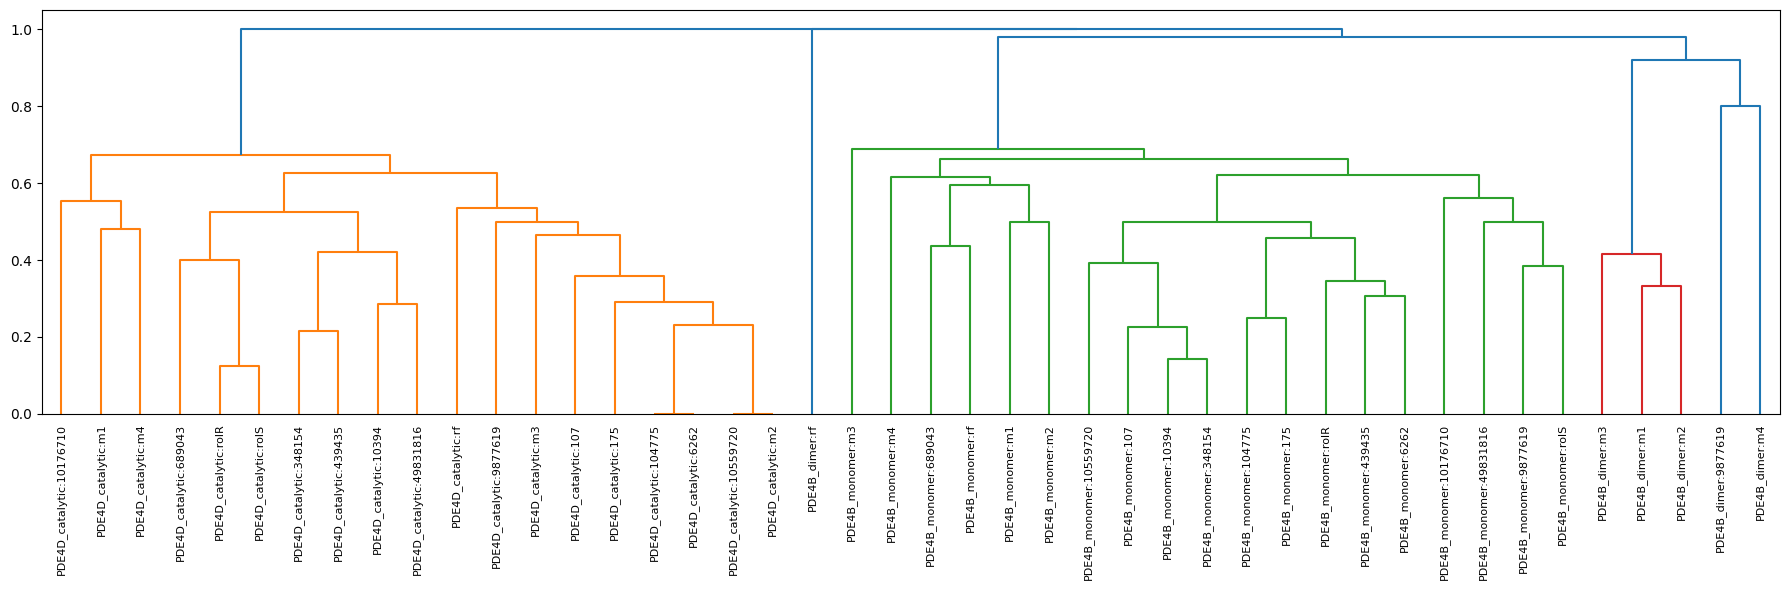

In [18]:
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

distance = pdist(fp.values, metric="jaccard")

Z = linkage(distance, method="average")

plt.figure(figsize=(18,6))

dendrogram(
    Z,
    labels=[f"{p}:{l}" for p, l in fp.index],
    leaf_rotation=90
)

plt.tight_layout()
plt.show()

# types analysis

In [12]:
df_lig.columns

Index(['protein', 'ligand', 'binding_site', 'interaction_type',
       'residue_number', 'residue_name', 'residue_chain', 'residue_id'],
      dtype='object')

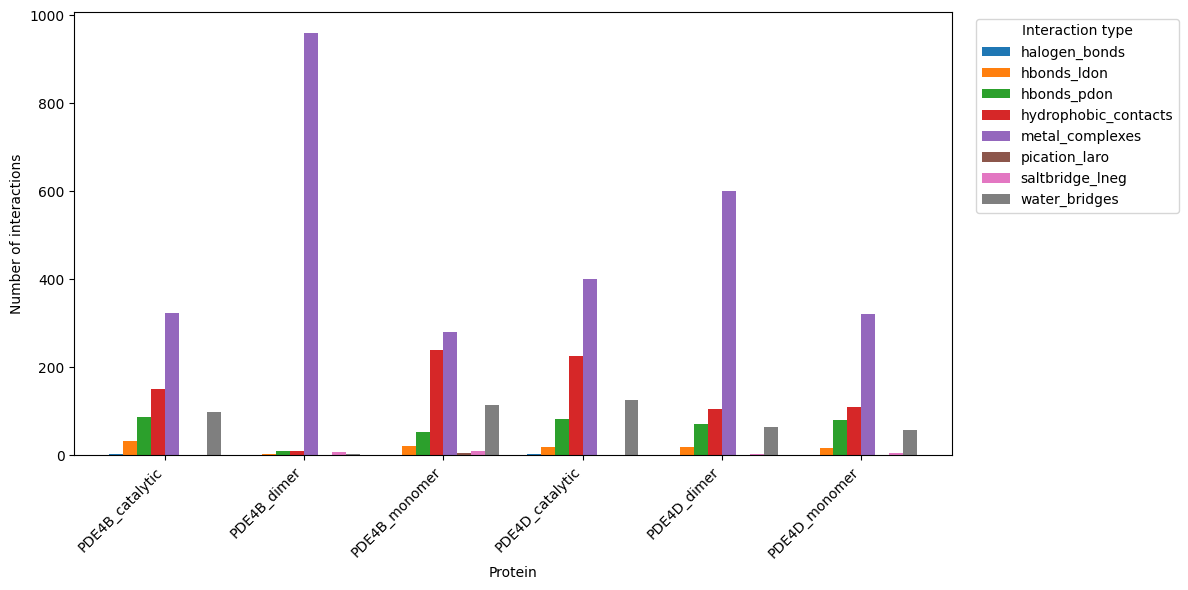

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

counts = (
    df.groupby(["protein", "interaction_type"])
      .size()
      .unstack(fill_value=0)
)

ax = counts.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

ax.set_xlabel("Protein")
ax.set_ylabel("Number of interactions")
ax.legend(title="Interaction type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

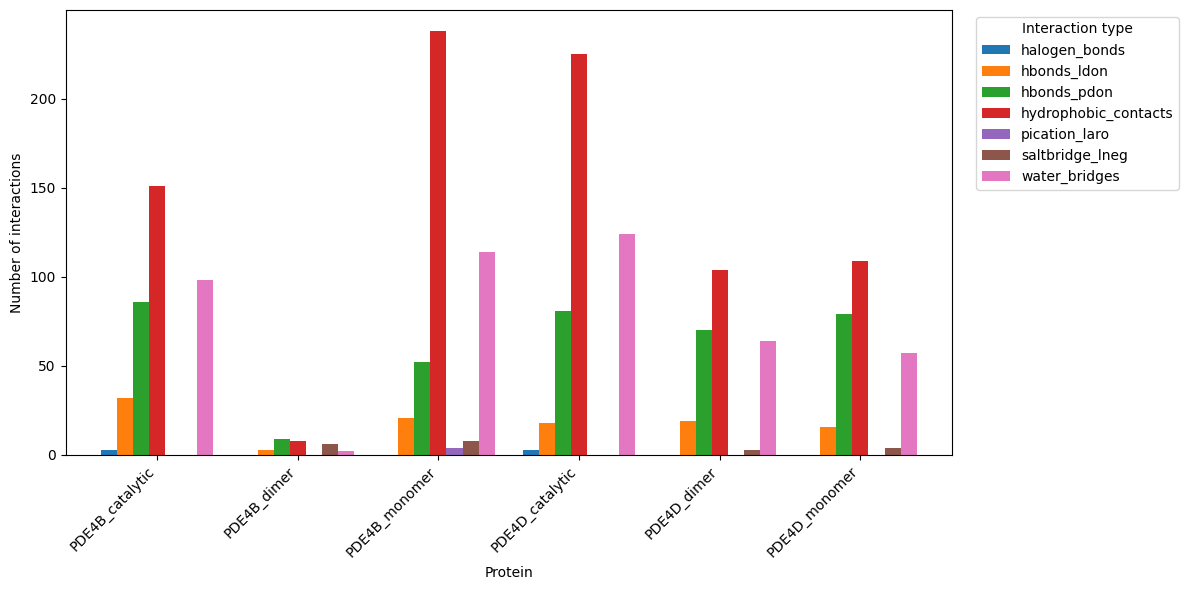

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

counts = (
    df_lig.groupby(["protein", "interaction_type"])
      .size()
      .unstack(fill_value=0)
)

ax = counts.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

ax.set_xlabel("Protein")
ax.set_ylabel("Number of interactions")
ax.legend(title="Interaction type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [25]:
counts

interaction_type,halogen_bonds,hbonds_ldon,hbonds_pdon,hydrophobic_contacts,pication_laro,saltbridge_lneg,water_bridges
protein,,,,,,,
PDE4B_catalytic,3,32,86,151,0,0,98
PDE4B_dimer,0,3,9,8,0,6,2
PDE4B_monomer,0,21,52,238,4,8,114
PDE4D_catalytic,3,18,81,225,0,0,124
PDE4D_dimer,0,19,70,104,0,3,64
PDE4D_monomer,0,16,79,109,0,4,57


In [26]:
counts.to_csv("interaction_counts.tsv", sep="\t")

In [27]:
for protein, group in df.groupby("protein"):
    print(protein, group["ligand"].nunique(), group["ligand"].unique())

PDE4B_catalytic 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4B_dimer 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4B_monomer 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4D_catalytic 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4D_dimer 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4D_monomer 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 

In [28]:
interaction_counts = (
    df.groupby(["protein", "ligand"])
      .size()
      .reset_index(name="n_interactions")
)

print(interaction_counts.to_string(index=False))

        protein   ligand  n_interactions
PDE4B_catalytic 10176710              42
PDE4B_catalytic    10394              36
PDE4B_catalytic   104775              23
PDE4B_catalytic 10559720              37
PDE4B_catalytic      107              33
PDE4B_catalytic      175              22
PDE4B_catalytic   348154              34
PDE4B_catalytic   439435              37
PDE4B_catalytic 49831816              40
PDE4B_catalytic     6262              26
PDE4B_catalytic   689043              35
PDE4B_catalytic  9877619              30
PDE4B_catalytic       m1              41
PDE4B_catalytic       m2              38
PDE4B_catalytic       m3              33
PDE4B_catalytic       m4              38
PDE4B_catalytic       m5              41
PDE4B_catalytic       rf              33
PDE4B_catalytic     rolR              39
PDE4B_catalytic     rolS              34
    PDE4B_dimer 10176710              48
    PDE4B_dimer    10394              48
    PDE4B_dimer   104775              48
    PDE4B_dimer 

In [29]:
for protein, group in df.groupby("protein"):
    print("\n", protein)
    print(group["ligand"].unique())


 PDE4B_catalytic
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4B_dimer
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4B_monomer
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4D_catalytic
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4D_dimer
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4D_monomer
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' '

In [30]:
from collections import Counter

pdb_file = "../pdbs/PDE4B_dimer_rolS.pdb"

atoms = []

with open(pdb_file) as f:
    for line in f:
        if line.startswith(("ATOM", "HETATM")):
            atom = line[12:16].strip()
            resname = line[17:20].strip()
            chain = line[21].strip()
            resid = line[22:26].strip()
            atoms.append((atom, resname, chain, resid))

print("Total atoms:", len(atoms))

Total atoms: 94461


In [31]:
from collections import Counter

counts = Counter(atoms)

duplicates = {k: v for k, v in counts.items() if v > 1}

print("Unique atom records:", len(counts))
print("Duplicated atom records:", len(duplicates))

for atom, n in list(duplicates.items())[:20]:
    print(n, atom)

Unique atom records: 33435
Duplicated atom records: 30198
3 ('N', 'VAL', 'A', '166')
3 ('CA', 'VAL', 'A', '166')
3 ('C', 'VAL', 'A', '166')
3 ('O', 'VAL', 'A', '166')
3 ('CB', 'VAL', 'A', '166')
3 ('CG1', 'VAL', 'A', '166')
3 ('CG2', 'VAL', 'A', '166')
3 ('HA', 'VAL', 'A', '166')
3 ('HB', 'VAL', 'A', '166')
3 ('1HG1', 'VAL', 'A', '166')
3 ('2HG1', 'VAL', 'A', '166')
3 ('3HG1', 'VAL', 'A', '166')
3 ('1HG2', 'VAL', 'A', '166')
3 ('2HG2', 'VAL', 'A', '166')
3 ('3HG2', 'VAL', 'A', '166')
2 ('HN2', 'VAL', 'A', '166')
2 ('HN1', 'VAL', 'A', '166')
2 ('HN3', 'VAL', 'A', '166')
2 ('HN4', 'VAL', 'A', '166')
6 ('N', 'THR', 'A', '167')


In [32]:
dimer = df[df["protein"] == "PDE4B_dimer"]

print(
    dimer.groupby(["ligand", "interaction_type"])
         .size()
         .unstack(fill_value=0)
         .to_string()
)

interaction_type  hbonds_ldon  hbonds_pdon  hydrophobic_contacts  metal_complexes  saltbridge_lneg  water_bridges
ligand                                                                                                           
10176710                    0            0                     0               48                0              0
10394                       0            0                     0               48                0              0
104775                      0            0                     0               48                0              0
10559720                    0            0                     0               48                0              0
107                         0            0                     0               48                0              0
175                         0            0                     0               48                0              0
348154                      0            0                     0               48       

In [33]:
print(
    dimer.groupby(["ligand", "residue_id"])
         .size()
         .sort_values(ascending=False)
         .head(30)
)

ligand    residue_id
10394     HIS446:B      16
10176710  HIS446:B      16
439435    HIS446:B      16
49831816  HIS446:B      16
6262      HIS446:B      16
348154    HIS446:B      16
107       HIS446:B      16
175       HIS446:B      16
10559720  HIS446:B      16
104775    HIS446:B      16
m5        HIS446:B      16
rolS      HIS446:B      16
rolR      HIS446:B      16
rf        HIS446:B      16
m3        HIS446:B      16
m4        HIS446:B      16
m2        HIS446:B      16
m1        HIS446:B      16
689043    HIS446:B      16
9877619   HIS446:B      16
m4        HIS281:B      12
m3        HIS281:B      12
rolR      HIS281:B      12
m5        HIS281:B      12
10176710  HIS281:B      12
10394     HIS281:B      12
m1        HIS281:B      12
m2        HIS281:B      12
9877619   HIS281:B      12
689043    HIS281:B      12
dtype: int64
